The 2025-26 NBA season has been one thats seen a very hotly contested race for the 8 playoff spots available in Eastern and Western Conference. Of those 16 teams, only two will make the NBA Finals, and one champion will be crowned. So, given past trends, current matchups, and one key outside factor, who will win the 2026 NBA Finals? In this project, I will be taking data from past NBA champions and comparing that to the 2025-26 stats of teams, to predict which team will come out on top in June.

In [8]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [9]:
df = pd.read_csv(r"C:\Users\dramm\Downloads\Advanced.csv")
df = pd.read_csv(r"C:\Users\dramm\Downloads\Team Summaries.csv")
df = pd.read_csv(r"C:\Users\dramm\Downloads\Opponent Stats Per Game.csv")
df = pd.read_csv(r"C:\Users\dramm\Downloads\Team Stats Per 100 Poss.csv")
df = pd.read_csv(r"C:\Users\dramm\Downloads\Opponent Stats Per 100 Poss.csv")
df = pd.read_csv(r"C:\Users\dramm\Downloads\Team Stats Per Game.csv")

Above are the 6 files of NBA statistics I loaded in, these stats are from Basketball Reference, basketball-reference.com, which will give me the statistics of teams from the past and present, including their advanced statistics and opponent statistics.

In [10]:
import pandas as pd
team_summary = pd.read_csv(r"C:\Users\dramm\Downloads\Team Summaries.csv")
per_100 = pd.read_csv(r"C:\Users\dramm\Downloads\Team Stats Per 100 Poss.csv")
opp_per_100 = pd.read_csv(r"C:\Users\dramm\Downloads\Opponent Stats Per 100 Poss.csv")
stats_per = pd.read_csv(r"C:\Users\dramm\Downloads\Team Stats Per Game.csv")
opp_stats_per = pd.read_csv(r"C:\Users\dramm\Downloads\Opponent Stats Per Game.csv")


In [11]:
team_summary.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1907 entries, 0 to 1906
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            1907 non-null   int64  
 1   lg                1907 non-null   object 
 2   team              1907 non-null   object 
 3   abbreviation      1818 non-null   object 
 4   playoffs          1907 non-null   bool   
 5   age               1843 non-null   float64
 6   w                 1817 non-null   float64
 7   l                 1817 non-null   float64
 8   pw                1906 non-null   float64
 9   pl                1906 non-null   float64
 10  mov               1906 non-null   float64
 11  sos               1906 non-null   float64
 12  srs               1906 non-null   float64
 13  o_rtg             1854 non-null   float64
 14  d_rtg             1854 non-null   float64
 15  n_rtg             1769 non-null   float64
 16  pace              1854 non-null   float64


These are all the statistics that the data tracks for teams. We will use 11 stats for winning. Those stats will be specified below.

Champion variable creation so we can use the dataset to train the model to predict this year's champ

In [12]:
dataFrame = team_summary[(team_summary["lg"] == "NBA") &(team_summary["season"] >= 1976)].copy()
dataFrame["season"].min(), dataFrame["season"].max()

(np.int64(1976), np.int64(2026))

Year interval set at 1976 as the oldest year so that we only use NBA information and not ABA or BAA information, which are the two older leagues that had different rules before they merged and became the NBA.

In [13]:
dataFrame.groupby("season")["team"].count().head()

season
1976    19
1977    23
1978    23
1979    23
1980    23
Name: team, dtype: int64

In [14]:
df = dataFrame
champions = {1976: "BOS",1977: "POR",1978: "WAS",1979: "SEA",1980: "LAL",1981: "BOS",1982: "LAL",
             1983: "PHI",1984: "BOS",1985: "LAL",1986: "BOS",1987: "LAL",1988: "LAL",1989: "DET",
             1990: "DET",1991: "CHI",1992: "CHI",1993: "CHI",1994: "HOU",1995: "HOU",1996: "CHI",
             1997: "CHI",1998: "CHI",1999: "SAS",2000: "LAL",2001: "LAL",2002: "LAL",2003: "SAS",
             2004: "DET",2005: "SAS",2006: "MIA",2007: "SAS",2008: "BOS",2009: "LAL",2010: "LAL",
             2011: "DAL",2012: "MIA",2013: "MIA",2014: "SAS",2015: "GSW",2016: "CLE",2017: "GSW",
             2018: "GSW",2019: "TOR",2020: "LAL",2021: "MIL",2022: "GSW",2023: "DEN",2024: "BOS",2025: "OKC"}

Each championship winner since 1976 (the year of ther merger) and add the column to the information.

In [15]:
dataFrame["Champion"] = (dataFrame["abbreviation"] == dataFrame["season"].map(champions)).astype(int)

Merge stats into 1 data frame so we can compare. Labeling teams that won a championship as 1 and non winners as 0 for easy comparison with visualization

In [16]:
stats = ["w","l","mov","o_rtg","d_rtg","n_rtg","ts_percent","e_fg_percent",
         "tov_percent","orb_percent","drb_percent","opp_e_fg_percent","opp_tov_percent" ]
comp = df.groupby("Champion")[stats].mean()
print(comp)

                  w          l       mov       o_rtg       d_rtg     n_rtg  \
Champion                                                                     
0         39.334322  40.699036 -0.245679  107.104429  107.349429 -0.254262   
1         59.081633  21.510204  6.922449  110.691837  103.500000  7.191837   

          ts_percent  e_fg_percent  tov_percent  orb_percent  drb_percent  \
Champion                                                                    
0           0.539394      0.496952    13.928857    28.448786    71.472714   
1           0.557000      0.517204    13.742857    29.475510    72.202041   

          opp_e_fg_percent  opp_tov_percent  
Champion                                     
0                 0.498229        13.922143  
1                 0.478347        13.930612  


Comparison between championship teams and non championship teams. Stats from left to right are wins, losses, margin of victory in points per game, offensive rating (points scored by a team per 100 possessions), defensive rating (how many points a team allows per 100 possessions),net rating (offensive rating minus defensive rating) , true shooting % (measures efficiency at scoring points, accounting for 2-point field goals, 3-point field goals, and free throws.), efficient fg % (adjusts traditional field goal percentage to account for the fact that three-point shots are worth 50% more than two-point shots), turnover %, offensive rebounding %, defensive rebounding %, opponent efficient fg %, and opponent turnover %.

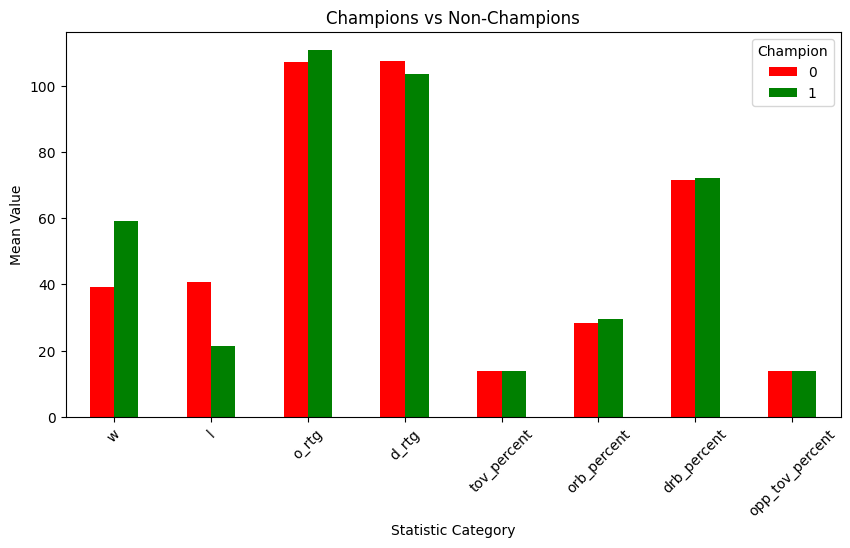

In [17]:
import matplotlib.pyplot as plt 
import pandas as pd
stats = ["w","l","o_rtg","d_rtg","tov_percent","orb_percent","drb_percent","opp_tov_percent"]
comp = df.groupby("Champion")[stats].mean()
comp.T.plot(kind="bar", figsize=(10,5), color=["red", "green"])
plt.title("Champions vs Non-Champions")
plt.xlabel("Statistic Category")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.show()

Bar chart to compare championship and non championship team stats. Shooting % will have it's own visualization. For defensive rating, a lower defensive rating is better, as it means you allow less points per possession, which is why the only bars non-champions have over champions are losses and defensive rating.

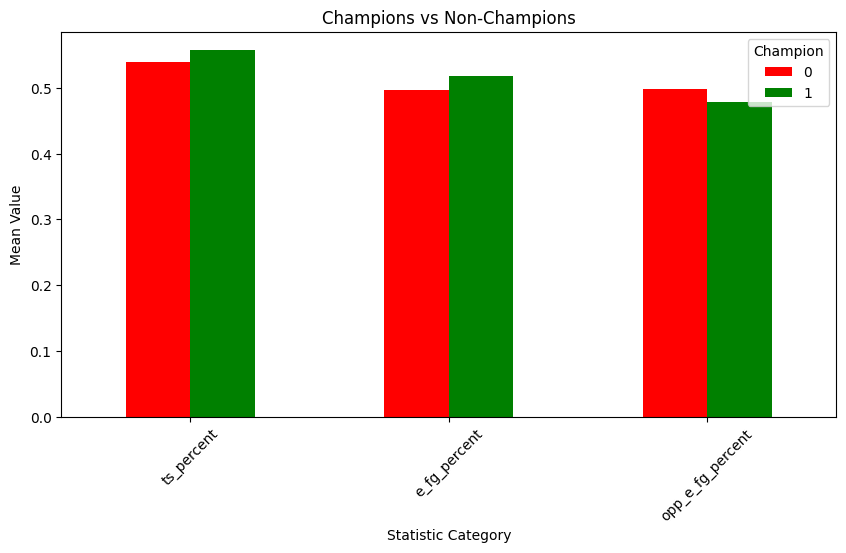

In [18]:
stats = ["ts_percent","e_fg_percent","opp_e_fg_percent"]
comp = df.groupby("Champion")[stats].mean()
comp = df.groupby("Champion")[stats].mean()
comp.T.plot(kind="bar", figsize=(10,5), color=["red", "green"])
plt.title("Champions vs Non-Champions")
plt.xlabel("Statistic Category")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.show()

In [19]:
stats = ["mov","o_rtg","d_rtg","n_rtg","ts_percent","e_fg_percent",
         "tov_percent","orb_percent","drb_percent","opp_e_fg_percent","opp_tov_percent"]

champion_avg_2015 = (
    dataFrame[(dataFrame["Champion"] == 1) & (dataFrame["season"] >= 2015)]
    [stats]
    .mean()
    .to_frame("ChampionAvg2015+")
    .T
)

teams = ["OKC","SAS","BOS","DET","NYK","MIN", "DEN"]
teams_2026 = (
    dataFrame[(dataFrame["season"] == 2026) & (dataFrame["abbreviation"].isin(teams))]
    .set_index("abbreviation")[stats]
)

comparison = pd.concat([champion_avg_2015, teams_2026], axis=0)
display(comparison.round(3))

,mov,o_rtg,d_rtg,n_rtg,ts_percent,e_fg_percent,tov_percent,orb_percent,drb_percent,opp_e_fg_percent,opp_tov_percent
ChampionAvg2015+,7.687,115.236,107.509,7.727,0.587,0.555,12.591,23.582,76.891,0.509,12.964
BOS,7.460,120.800,113.000,7.800,0.581,0.552,10.900,29.400,74.600,0.523,11.800
DEN,4.600,121.600,117.000,4.600,0.611,0.572,11.600,23.700,74.500,0.539,10.800
DET,7.810,117.000,109.200,7.800,0.576,0.540,13.000,31.000,74.100,0.516,15.100
MIN,4.480,117.700,113.200,4.500,0.595,0.563,12.800,26.300,74.700,0.532,13.100
NYK,5.770,119.500,113.600,5.900,0.586,0.554,11.900,29.000,76.300,0.538,12.800
OKC,11.260,118.900,107.700,11.200,0.600,0.561,11.400,22.200,74.000,0.518,14.800
SAS,6.710,118.000,111.300,6.700,0.589,0.552,12.000,25.800,76.600,0.523,11.900


Though the data for the champions we have dates back to 1976, the play style of the league has changed drastically in the past 10-20 years, with faster paced games, more talented scorers and defenders, and most of all, more 3 pointers being attempted by all teams. In 1980, the average NBA team attempted 2 three pointers per game. In the 2024-25 season, teams average over 35 a game. This has obviously led to an increase in teams' scoring output. From the years 1995 to 2008, the average PPG for an NBA was in the range of a low of 91.6 PPG in 1998-99, and a high of 99.9 in 2007-08. Thats 13 seasons where the league average never surpassed 100 PPG. By comparison, since 2018-19, the league average has been above 110 PPG, almost a 20 PPG difference.

So to make predict a champion for 2026, I have narrowed down the data to the averages of champions since 2015, when Steph Curry and the Warriors took the league by storm with a barrage of three pointers and shooting teams out of the gym, in order to have champion averages that better reflect the era of play. With this data, I found 7 teams whose averages most closely resemble that of a champion of the last 10 years. Those teams are the Thunder, Celtics, Spurs, Pistons, Knicks, Timberwolves, and Nuggets.

In [20]:
stats = ["mov","o_rtg","d_rtg","n_rtg","ts_percent","e_fg_percent",
         "tov_percent","orb_percent","drb_percent","opp_e_fg_percent","opp_tov_percent"]

champion_avg_2015 = (
    dataFrame[(dataFrame["Champion"] == 1) & (dataFrame["season"] >= 2015)]
    [stats]
    .mean()
    .to_frame("ChampionAvg2015+")
    .T
)

teams = ["OKC","SAS","BOS","DET"]
teams_2026 = (
    dataFrame[(dataFrame["season"] == 2026) & (dataFrame["abbreviation"].isin(teams))]
    .set_index("abbreviation")[stats]
)

comparison = pd.concat([champion_avg_2015, teams_2026], axis=0)
display(comparison.round(3))

,mov,o_rtg,d_rtg,n_rtg,ts_percent,e_fg_percent,tov_percent,orb_percent,drb_percent,opp_e_fg_percent,opp_tov_percent
ChampionAvg2015+,7.687,115.236,107.509,7.727,0.587,0.555,12.591,23.582,76.891,0.509,12.964
BOS,7.460,120.800,113.000,7.800,0.581,0.552,10.900,29.400,74.600,0.523,11.800
DET,7.810,117.000,109.200,7.800,0.576,0.540,13.000,31.000,74.100,0.516,15.100
OKC,11.260,118.900,107.700,11.200,0.600,0.561,11.400,22.200,74.000,0.518,14.800
SAS,6.710,118.000,111.300,6.700,0.589,0.552,12.000,25.800,76.600,0.523,11.900


Of the 7 teams I chose, I compared each one individually to see how many of the 11 categories they satisfy, and 4 of them matched a vast majority of those categories. Those teams are the Pistons (8 of 11), the Celtics, the Thunder, and the Spurs (all matched in 7 of 11 categories). 

Now, this project is being made as of March 20th, 2026. The Pistons star guard and franchise player, Cade Cunningham, who has been the biggest factor in Detroit's elevation and performance since 2024, suffered a collapsed lung which will see him miss an extended period of time. The significance of this is that we are less than a month away from the start of the first round of the playoffs, and this injury will most likely see him miss the first round. A championship contender cannot win a championship without their best player, and the Pistons being eliminated in the first round by the 8th seeded eastern team is now a very real possibility, so I have decided that although they best match the critera of a champion, the absence of Cade will be too big of a challenge to overcome in my opinion. So we will proceed with the Thunder, Celtics, and Spurs.

In [21]:
stats = ["mov","o_rtg","d_rtg","n_rtg","ts_percent","e_fg_percent",
         "tov_percent","orb_percent","drb_percent","opp_e_fg_percent","opp_tov_percent"]

champion_avg_2015 = (
    dataFrame[(dataFrame["Champion"] == 1) & (dataFrame["season"] >= 2015)]
    [stats]
    .mean()
    .to_frame("ChampionAvg2015+")
    .T
)

teams = ["OKC","SAS"]
teams_2026 = (
    dataFrame[(dataFrame["season"] == 2026) & (dataFrame["abbreviation"].isin(teams))]
    .set_index("abbreviation")[stats]
)

comparison = pd.concat([champion_avg_2015, teams_2026], axis=0)
display(comparison.round(3))

,mov,o_rtg,d_rtg,n_rtg,ts_percent,e_fg_percent,tov_percent,orb_percent,drb_percent,opp_e_fg_percent,opp_tov_percent
ChampionAvg2015+,7.687,115.236,107.509,7.727,0.587,0.555,12.591,23.582,76.891,0.509,12.964
OKC,11.260,118.900,107.700,11.200,0.600,0.561,11.400,22.200,74.000,0.518,14.800
SAS,6.710,118.000,111.300,6.700,0.589,0.552,12.000,25.800,76.600,0.523,11.900


The NBA Finals is held between the champion of the Western and Eastern Conference. Of the final 3 teams we have, the #1 seed Thunder and #2 seed Spurs are both in the West, meaning the two teams matching up in the Western Conference Finals in May is almost a forgone conclusion given how much better they are than the other teams in the west. Above I compared the two teams regular season performance. The Thunder are outperforming the Spurs in every metric except for offensive and defensive rebounding. Given the Thunder being the better team with their record and metrics, one could easily say that they would beat the Spurs and advance to the finals. However, the Spurs and Thunder have played each other 5 times this season, the most frequent matchup amongst all teams this season, due to the teams meeting in the NBA Cup final. Of those 5 games, the Spurs have won 4 of them, once on a neutral site in said NBA Cup Final, twice at home in San Antonio, and once in Oklahoma City. Though OKC's star player and reigning MVP/FMVP Shai Gilgeous-Alexander did not play in the latest meeting between the two, the Spurs obviously have the Thunder's number, they matchup very well across the board, with the bench depth to match the Thunder. Anchored by the alien/unicorn/monster hybrid, Victor Wembanyama, the Spurs have proved to be a bogey team for the Thunder. Shai has averaged 31.5 PPG, 4.5 rebounds per game, and 6.6 assists per game on 66.6% TS this season. But in the 4 games he's played against the Spurs this year, he averged 29.5 PPG, 4.5 rebounds, and 5.5 assists. Now these may not look like much of a difference, but the biggest difference is his efficieny, as in those 4 games he has averged 58.9% TS. So the Spurs have been able to make Shai less efficient in their 4 meetings, and this has obviously played a factor in why they're 4-1 against the Thunder this year. So based off the teams' head-to-head meetings in the regular season, I am picking the San Antonio Spurs to be the Western Conference's representative in the 2026 NBA Finals in June.

Given that the Boston Celtics led by Jaylen Brown are the only team in the East to satisfy the criteria for a true championship contender, I will pencil them in as the Eastern Conference's representative in the 2026 NBA Finals. 

In [22]:
df = pd.read_csv(r"C:\Users\dramm\Downloads\celtics_spurs_march6_stats.csv")

Above I have loaded in a table of the Celtics' and Spurs' stats since March 6th, 2026. The reason for this specific date will be explained after the table below.

In [23]:
stats_cols = [
    "Margin_of_Victory",
    "Offensive_Rating",
    "Defensive_Rating",
    "Net_Rating",
    "True_Shooting_Percent",
    "eFG_Percent",
    "Turnover_Percent",
    "Offensive_Rebound_Percent",
    "Defensive_Rebound_Percent",
    "Opponent_eFG_Percent",
    "Opponent_Turnover_Percent",
]

march6_comparison = (
    df[df["Team"].isin(["Celtics", "Spurs"])]
    .loc[:, ["Team"] + stats_cols]
    .set_index("Team")
)

display(march6_comparison.round(3))

,Margin_of_Victory,Offensive_Rating,Defensive_Rating,Net_Rating,True_Shooting_Percent,eFG_Percent,Turnover_Percent,Offensive_Rebound_Percent,Defensive_Rebound_Percent,Opponent_eFG_Percent,Opponent_Turnover_Percent
Team,,,,,,,,,,,
Celtics,8.6,116.3,105.1,11.2,59.4,55.4,12.9,26.7,73.5,50.7,12.4
Spurs,9.9,121.8,111.9,9.9,61.6,57.7,12.7,27.9,71.8,52.3,11.8


Above is the comparison between the Spurs and Celtics since March 6th, 2026. Since this period, the Celtics have played 7 games, going 5-2. The Spurs have played 8 games, going 7-1. Now you might want to know why I chose March 6th as the starting point. That is because after 298 days of rehab and recovery, the Celtics star forward and 4x consecutive All-NBA 1st Team player, Jayson Tatum, made his season debut on March 6th, 2026 after rupturing his Achilles on May 12th, 2025 in game 4 of the Eastern Conference Semifinals against the Knicks. So having already performed at a level up to standard with past NBA champions up to March 6th, the Celtics are now adding back Tatum, their best player and a guy who has been voted as a top 5 player for the past 4 years in a row. With that being said, a matchup between the Spurs and Celtics would be a clash of titans, two teams that excel on both the offensive and defensive ends of the floor. Of the 11 metrics I've been using throughout this data set, the Celtics have outperformed the Spurs in 5 categories (defensvie rating, net rating, defensive rebounding, opponent eFG%, and opponent turnover %). With a 6-5 split amongst the 11 categories in favor of the Spurs, a Finals matchup between the two would likely come down to a game 7, but with the two teams so evenly matched after all the filtering of numbers, this will come down to an intangible factor, experience.

The Spurs are en extremely talented team, led by back to back reigning rookie of the year winners Victor Wembanyama (2024) and Stephon Castle (2025), as well as 2x All-Star De'Aaron Fox. Wemby also is the clear favorite for Defensive Player of the Year, which will be his first as last season he did not win after getting injured and not meeting the minimum games played threshold to win the award then. The Spurs team is athletic, has lengthy defenders, can shoot the 3, and have a deep bench. All great factors for winning. However, this will be the first playoffs for many key players on the team, and the Spurs as an organization themselves have not made the playoffs since 2018-19. The Celtics on the other hand, have made the playoffs every year since the 2014-15 season, 11 seasons in a row. In those 11 playoff runs, they've made the Conference Finals 6 times, with all 6 coming in the last 9 runs, and they've made the finals twice, once in 2021-22 when they lost to the Warriors in 6 games, and the otherin 2023-24 when they defeated the Mavericks in 5 games. Throughout all of these deep playoff runs, the Celtics have been led by Jayson Tatum and Jaylen Brown, two top 10 players in the NBA. With experience playing the biggest factor due to the teams not being able to be clearly seperated by talent or numbers, I am picking the Boston Celtics as the 2025-26 NBA Champions. I believe the Celtics adding an X-factor and true difference maker with playoff winning experience like Tatum to an already well-oiled championship contender will be the deciding factor in a series over the unexperienced Spurs and Wemby, who could fold under the bright lights of the Finals.

Now, after all the regular metrics, below are my learning models that I used to see if they would also predict the same champion that I picked. In order, they are a logistic regression model, random forest, and a decision tree.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=500))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_valid)
y_prob_log = log_model.predict_proba(X_valid)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_valid, y_pred_log))
print("Precision:", precision_score(y_valid, y_pred_log, zero_division=0))
print("Recall:", recall_score(y_valid, y_pred_log, zero_division=0))

Logistic Regression Results
Accuracy: 0.8248175182481752
Precision: 0.16071428571428573
Recall: 0.9


In [50]:
log_model.fit(X, y)

test_2026["Logistic_Prob"] = log_model.predict_proba(test_2026[features])[:, 1]

display(test_2026[["team", "abbreviation", "season", "Logistic_Prob"]].sort_values(
    "Logistic_Prob", ascending=False
))

,team,abbreviation,season,Logistic_Prob
20,Oklahoma City Thunder,OKC,2026,0.853247
10,Houston Rockets,HOU,2026,0.847177
1,Boston Celtics,BOS,2026,0.832731
8,Detroit Pistons,DET,2026,0.758047
26,San Antonio Spurs,SAS,2026,0.725346
19,New York Knicks,NYK,2026,0.583593
17,Minnesota Timberwolves,MIN,2026,0.423036
4,Charlotte Hornets,CHO,2026,0.314543
5,Cleveland Cavaliers,CLE,2026,0.181853
7,Denver Nuggets,DEN,2026,0.175911


The logistic regression model predicts the Thunder to be the 2026 champion.

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_valid)
y_prob_rf = rf_model.predict_proba(X_valid)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_valid, y_pred_rf))
print("Precision:", precision_score(y_valid, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_valid, y_pred_rf, zero_division=0))

Random Forest Results
Accuracy: 0.9343065693430657
Precision: 0.16666666666666666
Recall: 0.2


In [52]:
rf_model.fit(X, y)

test_2026["RandomForest_Prob"] = rf_model.predict_proba(test_2026[features])[:, 1]

display(test_2026[["team", "abbreviation", "season", "RandomForest_Prob"]].sort_values(
    "RandomForest_Prob", ascending=False
))

,team,abbreviation,season,RandomForest_Prob
20,Oklahoma City Thunder,OKC,2026,0.544842
8,Detroit Pistons,DET,2026,0.307171
26,San Antonio Spurs,SAS,2026,0.266426
19,New York Knicks,NYK,2026,0.222709
1,Boston Celtics,BOS,2026,0.194588
7,Denver Nuggets,DEN,2026,0.143844
17,Minnesota Timberwolves,MIN,2026,0.103401
5,Cleveland Cavaliers,CLE,2026,0.095327
4,Charlotte Hornets,CHO,2026,0.089030
10,Houston Rockets,HOU,2026,0.084906


The random forest model also predicts the Thunder to be the 2026 champion.

In [53]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_valid)
y_prob_dt = dt_model.predict_proba(X_valid)[:, 1]

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_valid, y_pred_dt))
print("Precision:", precision_score(y_valid, y_pred_dt, zero_division=0))
print("Recall:", recall_score(y_valid, y_pred_dt, zero_division=0))

Decision Tree Results
Accuracy: 0.8613138686131386
Precision: 0.13157894736842105
Recall: 0.5


In [31]:
dt_model.fit(X, y)

test_2026["DecisionTree_Prob"] = dt_model.predict_proba(test_2026[features])[:, 1]

display(test_2026[["team", "abbreviation", "season", "DecisionTree_Prob"]].sort_values(
    "DecisionTree_Prob", ascending=False
))

,team,abbreviation,season,DecisionTree_Prob
20,Oklahoma City Thunder,OKC,2026,0.982959
17,Minnesota Timberwolves,MIN,2026,0.861341
2,Brooklyn Nets,BRK,2026,0.000000
3,Chicago Bulls,CHI,2026,0.000000
0,Atlanta Hawks,ATL,2026,0.000000
1,Boston Celtics,BOS,2026,0.000000
6,Dallas Mavericks,DAL,2026,0.000000
7,Denver Nuggets,DEN,2026,0.000000
8,Detroit Pistons,DET,2026,0.000000
9,Golden State Warriors,GSW,2026,0.000000


The decision tree, like the other 2 models, also predicts the Thunder to be the 2026 champion.

In [54]:
comparison = test_2026[["team", "abbreviation", "season"]].copy()
comparison["Logistic_Prob"] = log_model.predict_proba(test_2026[features])[:, 1]
comparison["RandomForest_Prob"] = rf_model.predict_proba(test_2026[features])[:, 1]
comparison["DecisionTree_Prob"] = dt_model.predict_proba(test_2026[features])[:, 1]

display(comparison.sort_values("Logistic_Prob", ascending=False))

,team,abbreviation,season,Logistic_Prob,RandomForest_Prob,DecisionTree_Prob
20,Oklahoma City Thunder,OKC,2026,0.853247,0.544842,0.973819
10,Houston Rockets,HOU,2026,0.847177,0.084906,0.000000
1,Boston Celtics,BOS,2026,0.832731,0.194588,0.879271
8,Detroit Pistons,DET,2026,0.758047,0.307171,0.879271
26,San Antonio Spurs,SAS,2026,0.725346,0.266426,0.879271
19,New York Knicks,NYK,2026,0.583593,0.222709,0.879271
17,Minnesota Timberwolves,MIN,2026,0.423036,0.103401,0.000000
4,Charlotte Hornets,CHO,2026,0.314543,0.089030,0.000000
5,Cleveland Cavaliers,CLE,2026,0.181853,0.095327,0.000000
7,Denver Nuggets,DEN,2026,0.175911,0.143844,0.000000


Based on just raw statistics, with no context, outside knowledge, or any other extrernal influences, the OKC Thunder are the unanimous pick amongst all 3 learning models I used. This is a good pick by the models, as the Thunder are the defending champions and are the current betting favorites to win. But as I explained in the project before I used my models, there are other factors that matter very much in this prediction that cannot necessarily be added as a variable in my models to take in to account, like the Thunder's record vs the Spurs, or the fact that the Celtics just added another superstar to their team and are on fire heading into the playoffs.